# Clasificación de gestos de mano mediante señales EMG utilizando redes LSTM

In [15]:
from google.colab import drive
drive.mount('/content/drive')
import os
import glob
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
import hashlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
baseDir = "/content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG"

datasetPath = os.path.join(baseDir, "Dataset")
modelsDir   = os.path.join(baseDir, "Models", "Train models")
scalersDir  = os.path.join(baseDir, "Scalers")

modelPath  = os.path.join(modelsDir, "EMGBiLSTMModel3.pt")
scalerPath = os.path.join(scalersDir, "scaler3.save")

trainingCurvesPath = os.path.join(baseDir, "training_curves3.npz")

print("datasetPath:", datasetPath)
print("modelPath:", modelPath)
print("scalerPath:", scalerPath)
print("trainingCurvesPath:", trainingCurvesPath)

datasetPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset
modelPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel3.pt
scalerPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler.save
trainingCurvesPath: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/training_curves3.npz


In [17]:
txtFiles = sorted(glob.glob(os.path.join(datasetPath, "**/*.txt"), recursive=True))
print(f"Archivos encontrados: {len(txtFiles)}")

Archivos encontrados: 82


In [18]:


def loadFile(filePath):
    try:
        dfRaw = pd.read_csv(
            filePath,
            sep=r"\s+",
            engine="python",
            header=None,
            on_bad_lines='skip'
        )

        if dfRaw.shape[1] != 10:
            print(f"Archivo con columnas inesperadas: {filePath} : {dfRaw.shape[1]} columnas")
            return pd.DataFrame()

        dfRaw.columns = ['time'] + [f'ch{i}' for i in range(1, 9)] + ['label']
        dfRaw = dfRaw[dfRaw['label'] != 0]
        return dfRaw

    except Exception as e:
        print(f"Error al leer {filePath}: {e}")
        return pd.DataFrame()


allDataDf = pd.concat([loadFile(f) for f in txtFiles], ignore_index=True)
print(allDataDf.head())
print(allDataDf['label'].value_counts())

Archivo con columnas inesperadas: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Dataset/README.txt : 3 columnas
   time       ch1       ch2       ch3       ch4       ch5       ch6       ch7  \
0  time  channel1  channel2  channel3  channel4  channel5  channel6  channel7   
1     1     1e-05    -2e-05    -1e-05    -3e-05         0    -1e-05         0   
2     5     1e-05    -2e-05    -1e-05    -3e-05         0    -1e-05         0   
3     6    -1e-05     1e-05     2e-05         0     1e-05    -2e-05    -1e-05   
4     7    -1e-05     1e-05     2e-05         0     1e-05    -2e-05    -1e-05   

        ch8  label  
0  channel8  class  
1    -1e-05      0  
2    -1e-05      0  
3     1e-05      0  
4     1e-05      0  
label
0        3083237
6         282646
5         282008
1         280847
4         280543
3         279131
2         272798
7          17125
class         81
Name: count, dtype: int64


In [19]:
allDataDf = allDataDf.apply(pd.to_numeric, errors='coerce')
allDataDf = allDataDf.dropna().reset_index(drop=True)

print("Shape después de limpiar filas no numéricas:", allDataDf.shape)

Shape después de limpiar filas no numéricas: (4778335, 10)


In [20]:
dfChannels = [f'ch{i}' for i in range(1, 9)]

scaler = StandardScaler()
allDataDf[dfChannels] = scaler.fit_transform(allDataDf[dfChannels])

print(allDataDf[dfChannels].describe().T[['mean', 'std']])

             mean  std
ch1 -3.574770e-17  1.0
ch2  6.548416e-17  1.0
ch3  5.701193e-17  1.0
ch4 -1.475931e-17  1.0
ch5 -2.667992e-17  1.0
ch6 -2.399884e-17  1.0
ch7 -9.445481e-18  1.0
ch8 -3.703991e-17  1.0


In [21]:
def createSlidingWindows(dataframe, channels, windowSize=200, stepSize=100):
    x, y = [], []
    dataArray = dataframe[channels + ['label']].values
    totalLen = len(dataArray)

    for start in range(0, totalLen - windowSize, stepSize):
        end = start + windowSize
        window = dataArray[start:end]
        segment = window[:, :-1]
        labels = window[:, -1]

        if np.all(labels == labels[0]):
            x.append(segment)
            y.append(int(labels[0]))

    return np.array(x), np.array(y)

In [43]:
windowSize = 200
stepSize = 100

xData, yData = createSlidingWindows(allDataDf, dfChannels, windowSize, stepSize)

print("X shape:", xData.shape)
print("y shape:", yData.shape)
print("Clases disponibles:", np.unique(yData, return_counts=True))

X shape: (43878, 200, 8)
y shape: (43878,)
Clases disponibles: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([28869,  2490,  2405,  2473,  2486,  2492,  2511,   152]))


In [44]:
augmentedX, augmentedY = [], []
for x, y in zip(xData, yData):
    augmentedX.append(x)
    augmentedY.append(y)
    if y in [1, 7]:
        augmentedX.append(x)
        augmentedY.append(y)

xData = np.array(augmentedX)
yData = np.array(augmentedY)
print("Nueva forma con aumento:", xData.shape, yData.shape)

Nueva forma con aumento: (46520, 200, 8) (46520,)


In [45]:
xTrain, xTestVal, yTrain, yTestVal = train_test_split(
    xData, yData, test_size=0.2, stratify=yData, random_state=42
)

xVal, xTest, yVal, yTest = train_test_split(
    xTestVal, yTestVal, test_size=0.5, stratify=yTestVal, random_state=42
)

print("Train:", xTrain.shape, yTrain.shape)
print("Val:", xVal.shape, yVal.shape)
print("Test:", xTest.shape, yTest.shape)

Train: (37216, 200, 8) (37216,)
Val: (4652, 200, 8) (4652,)
Test: (4652, 200, 8) (4652,)


In [46]:
testCasesDir = os.path.join(baseDir, "TestCases")
os.makedirs(testCasesDir, exist_ok=True)

print("\n===== Archivos que deberían ir a TestCases =====")
for f in test_files:
    print(os.path.basename(f))

print("\n===== Copiando archivos =====")

copied = 0
errors = []

for filePath in test_files:
    try:
        if not os.path.exists(filePath):
            print("No existe:", filePath)
            errors.append(filePath)
            continue

        filename = os.path.basename(filePath)
        dest = os.path.join(testCasesDir, filename)

        shutil.copy2(filePath, dest)
        print("Copiado:", filename)
        copied += 1

    except Exception as e:
        print("ERROR copiando", filePath, "→", e)
        errors.append(filePath)

print("\nTOTAL COPIADOS:", copied)
print("ERRORES:", len(errors))


===== Archivos que deberían ir a TestCases =====
1_raw_data_12-12_25.04.16.txt
1_raw_data_13-12_22.03.16.txt
1_raw_data_11-35_28.03.16.txt
2_raw_data_12-14_25.04.16.txt
1_raw_data_11-08_21.03.16.txt
1_raw_data_08-49_13.04.16.txt
1_raw_data_10-38_11.04.16.txt
2_raw_data_12-20_06.04.16.txt
1_raw_data_09-32_11.04.16.txt
1_raw_data_18-48_22.03.16.txt
2_raw_data_14-53_24.04.16.txt
2_raw_data_11-20_23.03.16.txt
1_raw_data_10-03_13.04.16.txt
2_raw_data_12-37_21.03.16.txt
2_raw_data_10-05_13.04.16.txt
2_raw_data_13-19_05.04.16.txt
1_raw_data_10-38_11.04.16.txt

===== Copiando archivos =====
Copiado: 1_raw_data_12-12_25.04.16.txt
Copiado: 1_raw_data_13-12_22.03.16.txt
Copiado: 1_raw_data_11-35_28.03.16.txt
Copiado: 2_raw_data_12-14_25.04.16.txt
Copiado: 1_raw_data_11-08_21.03.16.txt
Copiado: 1_raw_data_08-49_13.04.16.txt
Copiado: 1_raw_data_10-38_11.04.16.txt
Copiado: 2_raw_data_12-20_06.04.16.txt
Copiado: 1_raw_data_09-32_11.04.16.txt
Copiado: 1_raw_data_18-48_22.03.16.txt
Copiado: 2_raw_data

In [47]:
class EMGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [48]:
batchSize = 64

dfTrain = EMGDataset(xTrain, yTrain)
dfVal   = EMGDataset(xVal, yVal)
dfTest  = EMGDataset(xTest, yTest)

loaderTrain = DataLoader(dfTrain, batch_size=batchSize, shuffle=True)
loaderVal  = DataLoader(dfVal, batch_size=batchSize, shuffle=False)
loaderTest  = DataLoader(dfTest, batch_size=batchSize, shuffle=False)

In [49]:
class EMGBiLSTMClassifier(nn.Module):
    def __init__(self, in_channels=8, num_classes=8):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_channels,
            hidden_size=64,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

model = EMGBiLSTMClassifier().to(device)

Usando dispositivo: cuda


In [51]:
epochs = 200
learningRate = 0.001

class_weights = torch.tensor([1.0, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=learningRate)

def evaluate(model, dataLoader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch, yBatch = xBatch.to(device), yBatch.to(device)
            outputs = model(xBatch)
            _, predicted = torch.max(outputs.data, 1)
            total += yBatch.size(0)
            correct += (predicted == yBatch).sum().item()

    return 100 * correct / total

In [52]:
lossesTrain = []
accuraciesVal = []

best_val_acc = 0.0

print(f"Se guardará el mejor modelo en: {modelPath}")

for epoch in range(epochs):
    model.train()
    runningLoss = 0.0
    progressBar = tqdm(loaderTrain, desc=f"Época {epoch+1}/{epochs}")

    for xBatch, yBatch in progressBar:
        xBatch, yBatch = xBatch.to(device), yBatch.to(device)
        optimizer.zero_grad()

        outputs = model(xBatch)
        loss = criterion(outputs, yBatch)
        loss.backward()
        optimizer.step()

        runningLoss += loss.item()
        progressBar.set_postfix(loss=loss.item())

    avg_loss = runningLoss / len(loaderTrain)
    val_acc = evaluate(model, loaderVal)
    lossesTrain.append(avg_loss)
    accuraciesVal.append(val_acc)

    print(f"=> Época {epoch+1}: Loss={avg_loss:.4f} | Val Acc={val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), modelPath)
        print(f"Nuevo mejor modelo guardado (Val Acc = {best_val_acc:.2f}%)")

print("Entrenamiento finalizado.")
print(f"Mejor accuracy de validación: {best_val_acc:.2f}%")

Se guardará el mejor modelo en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel3.pt


Época 1/200: 100%|██████████| 582/582 [00:04<00:00, 142.32it/s, loss=0.993]


=> Época 1: Loss=1.2615 | Val Acc=62.06%
Nuevo mejor modelo guardado (Val Acc = 62.06%)


Época 2/200: 100%|██████████| 582/582 [00:04<00:00, 143.42it/s, loss=1.15]


=> Época 2: Loss=1.0298 | Val Acc=62.06%


...

=> Época 198: Loss=0.0985 | Val Acc=79.66%


Época 199/200: 100%|██████████| 582/582 [00:04<00:00, 144.10it/s, loss=0.0407]


=> Época 199: Loss=0.0961 | Val Acc=79.08%


Época 200/200: 100%|██████████| 582/582 [00:04<00:00, 141.85it/s, loss=0.132]


=> Época 200: Loss=0.0884 | Val Acc=80.37%
Nuevo mejor modelo guardado (Val Acc = 80.37%)
Entrenamiento finalizado.
Mejor accuracy de validación: 80.37%


In [53]:
def getAllPreds(model, dataLoader):
    model.eval()
    yTrue, yPred = [], []

    with torch.no_grad():
        for xBatch, yBatch in dataLoader:
            xBatch = xBatch.to(device)
            outputs = model(xBatch)
            _, predicted = torch.max(outputs.data, 1)

            yTrue.extend(yBatch.cpu().numpy())
            yPred.extend(predicted.cpu().numpy())

    return np.array(yTrue), np.array(yPred)

yTrueTest, yPredTest = getAllPreds(model, loaderTest)

accuracyTest = np.mean(yTrueTest == yPredTest) * 100

maeTest = mean_absolute_error(yTrueTest, yPredTest)
biasTest = np.mean(yPredTest - yTrueTest)
varTest = np.var(yPredTest)

print(f"Accuracy en test set: {accuracyTest:.2f}%")
print(f"MAE (Test): {maeTest:.4f}")
print(f"Bias (Test): {biasTest:.4f}")
print(f"Varianza (Test): {varTest:.4f}")

Accuracy en test set: 79.19%
MAE (Test): 0.6520
Bias (Test): 0.0294
Varianza (Test): 3.8345


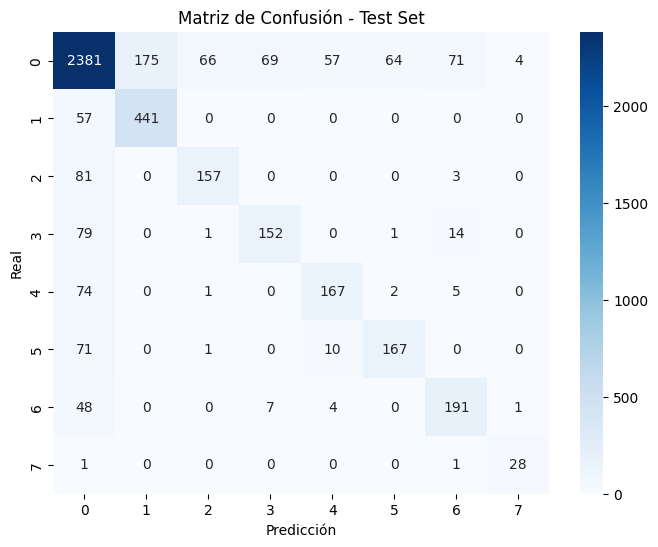

In [54]:
cm = confusion_matrix(yTrueTest, yPredTest)
labels = np.unique(yData)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test Set')
plt.show()

In [55]:
print("Reporte de clasificación:")
print(classification_report(yTrueTest, yPredTest, digits=4))

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.8528    0.8247    0.8385      2887
           1     0.7159    0.8855    0.7917       498
           2     0.6947    0.6515    0.6724       241
           3     0.6667    0.6154    0.6400       247
           4     0.7017    0.6707    0.6858       249
           5     0.7137    0.6707    0.6915       249
           6     0.6702    0.7610    0.7127       251
           7     0.8485    0.9333    0.8889        30

    accuracy                         0.7919      4652
   macro avg     0.7330    0.7516    0.7402      4652
weighted avg     0.7947    0.7919    0.7919      4652



In [56]:
torch.save(model.state_dict(), modelPath)
joblib.dump(scaler, scalerPath)
np.savez(trainingCurvesPath,
         lossesTrain=np.array(lossesTrain),
         accuraciesVal=np.array(accuraciesVal),
         accuracyTest=np.array([accuracyTest]),
         maeTest=np.array([maeTest]),
         biasTest=np.array([biasTest]),
         varTest=np.array([varTest]))

print("Modelo guardado en:", modelPath)
print("Scaler guardado en:", scalerPath)
print("Curvas de entrenamiento guardadas en training_curves3.npz")

Modelo guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Models/Train models/EMGBiLSTMModel3.pt
Scaler guardado en: /content/drive/MyDrive/ConcentracionIA/Periodo2/Mod2. Tecnicas y arquitecturas de deep learning/Proyecto/DeepEMG/Scalers/scaler.save
Curvas de entrenamiento guardadas en training_curves3.npz


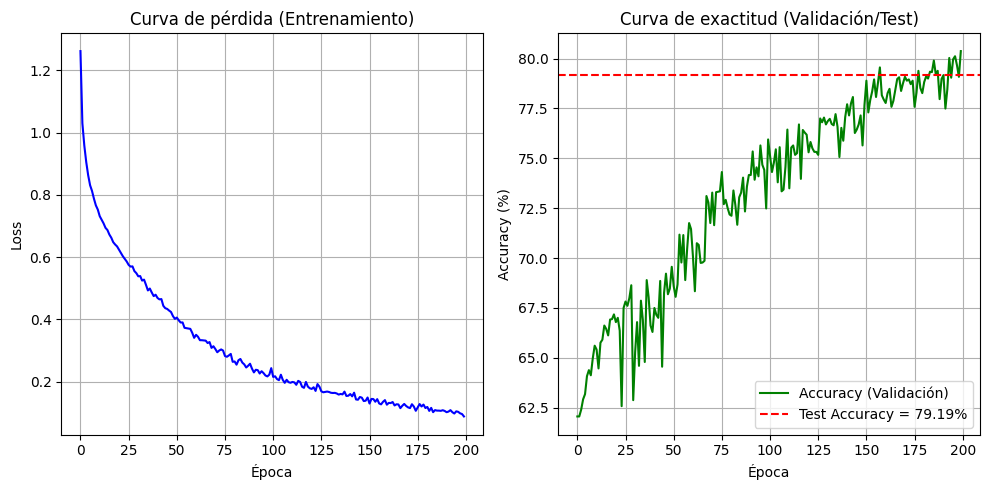

In [57]:
data = np.load(trainingCurvesPath, allow_pickle=True)
lossesTrain = data["lossesTrain"]
accuraciesVal = data["accuraciesVal"]
accuracyTest = data["accuracyTest"][0]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(lossesTrain, label="Loss (Train)", color="blue")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida (Entrenamiento)")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(accuraciesVal, label="Accuracy (Validación)", color="green")
plt.axhline(y=accuracyTest, color="red", linestyle="--",
            label=f"Test Accuracy = {accuracyTest:.2f}%")
plt.xlabel("Época")
plt.ylabel("Accuracy (%)")
plt.title("Curva de exactitud (Validación/Test)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()